In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

first, we simulate ad data

each user:
- sees impressions
- may click
- may convert

we create realistic dataset similar to ads platform

this will be our base data without privacy noise

In [2]:
def simulate_ads(n=100000, seed=42):
    np.random.seed(seed)

    impressions = np.random.randint(5, 50, n)

    ctr = 0.05
    clicks = np.random.binomial(impressions, ctr)

    cvr = 0.1
    conversions = np.random.binomial(clicks, cvr)

    df = pd.DataFrame({
        "impressions": impressions,
        "clicks": clicks,
        "conversions": conversions
    })

    return df

df = simulate_ads()
df.head()

,impressions,clicks,conversions
0,43,4,1
1,33,0,0
2,19,0,0
3,47,0,0
4,12,0,0


now we prepare data for modeling

goal:
predict conversion probability

features:
- impressions
- clicks

target:
- whether conversion happened or not

In [3]:
X = df[["impressions", "clicks"]]
y = (df["conversions"] > 0).astype(int)

first, we train model on clean data

this is best case scenario

we measure:
- accuracy
- auc

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

pred = model.predict(X)
prob = model.predict_proba(X)[:, 1]

baseline_acc = accuracy_score(y, pred)
baseline_auc = roc_auc_score(y, prob)

baseline_acc, baseline_auc

(0.87195, 0.7782778905330288)

now we add privacy noise

idea:
we add laplace noise to clicks and conversions

epsilon controls privacy:
- small epsilon = more noise (high privacy)
- large epsilon = less noise (low privacy)

we test multiple epsilon values

In [5]:
def add_dp_noise(df, epsilon):
    noisy = df.copy()

    scale = 1 / epsilon

    noise_clicks = np.random.laplace(0, scale, size=len(df))
    noise_conv = np.random.laplace(0, scale, size=len(df))

    noisy["clicks"] = np.maximum(0, noisy["clicks"] + noise_clicks).astype(int)
    noisy["conversions"] = np.maximum(0, noisy["conversions"] + noise_conv).astype(int)

    return noisy

epsilons = [0.1, 0.5, 1, 5, 10]

now for each epsilon:

- add noise
- train model
- evaluate performance

this shows how accuracy changes with privacy

In [6]:
results = []

for eps in epsilons:
    noisy_df = add_dp_noise(df, eps)

    X_noisy = noisy_df[["impressions", "clicks"]]
    y_noisy = (noisy_df["conversions"] > 0).astype(int)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_noisy, y_noisy)

    pred = model.predict(X_noisy)
    prob = model.predict_proba(X_noisy)[:, 1]

    acc = accuracy_score(y_noisy, pred)
    auc = roc_auc_score(y_noisy, prob)

    results.append((eps, acc, auc))

results

[(0.1, 0.54057, 0.5045926937157795),
 (0.5, 0.67161, 0.5183271435285223),
 (1, 0.77206, 0.5475448586227782),
 (5, 0.92993, 0.7400980001901565),
 (10, 0.93253, 0.7527674770716254)]

now we plot performance vs epsilon

x-axis:
privacy level (epsilon)

y-axis:
model performance

this shows tradeoff:
more privacy → lower performance

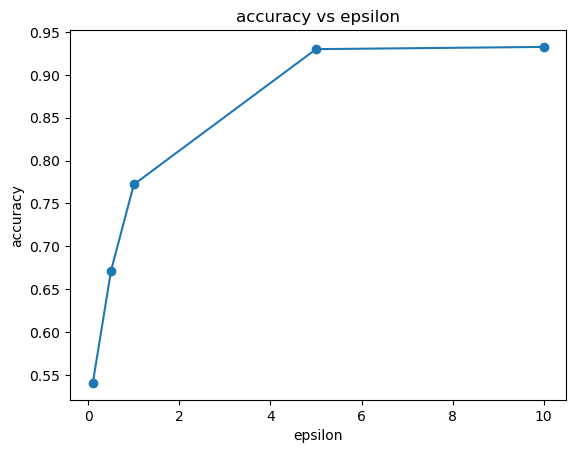

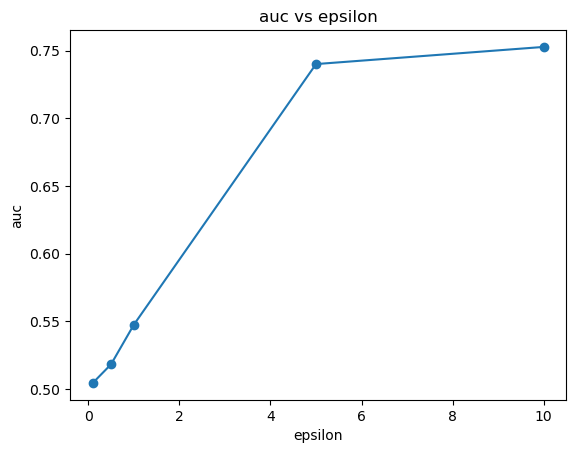

In [7]:
eps_vals = [r[0] for r in results]
acc_vals = [r[1] for r in results]
auc_vals = [r[2] for r in results]

plt.figure()
plt.plot(eps_vals, acc_vals, marker='o')
plt.title("accuracy vs epsilon")
plt.xlabel("epsilon")
plt.ylabel("accuracy")
plt.show()

plt.figure()
plt.plot(eps_vals, auc_vals, marker='o')
plt.title("auc vs epsilon")
plt.xlabel("epsilon")
plt.ylabel("auc")
plt.show()

now we compare noisy results with baseline

this helps us see how much performance is lost due to differential privacy thing

In [8]:
print("baseline accuracy:", baseline_acc)
print("baseline auc:", baseline_auc)

for eps, acc, auc in results:
    print(f"epsilon={eps} -> acc={acc:.4f}, auc={auc:.4f}")

baseline accuracy: 0.87195
baseline auc: 0.7782778905330288
epsilon=0.1 -> acc=0.5406, auc=0.5046
epsilon=0.5 -> acc=0.6716, auc=0.5183
epsilon=1 -> acc=0.7721, auc=0.5475
epsilon=5 -> acc=0.9299, auc=0.7401
epsilon=10 -> acc=0.9325, auc=0.7528


## overall idea

we studied how privacy affects our ability to measure and predict user behavior
by adding noise (differential privacy)

---

## baseline (no privacy)

accuracy is about 0.87  
auc is about 0.78  

this is our best case

model has full information, no noise

so performance is high

---

## very high privacy (epsilon = 0.1)

accuracy is about 0.54  
auc is about 0.50  

this is almost random

means:
- noise is too high  
- signal is destroyed  

model cannot learn anything useful

---

## moderate privacy (epsilon = 0.5 to 1)

accuracy improves from about 0.67 to about 0.77  
auc improves from about 0.51 to about 0.55  

model starts learning something

but still weak

means:
- some signal is present  
- but noise is still hurting performance  

---

## low privacy (epsilon = 5)

accuracy is about 0.93  
auc is about 0.74  

performance is close to baseline

means:
- noise is small  
- most signal is preserved  

this is a good balance region

---

## very low privacy (epsilon = 10)

accuracy is about 0.93  
auc is about 0.75  

almost same as epsilon = 5

means:
- increasing epsilon further gives very small improvement  

so diminishing returns

---

## inferring the plots

- accuracy and auc both increase as epsilon increases  
- curve rises fast at beginning, then flattens  

so likely
- biggest gain happens when moving from very high to moderate privacy  
- after that, improvement slows down  

---

## takeaway

there is a clear tradeoff:

- more privacy (low epsilon) leads to worse measurement  
- less privacy (high epsilon) leads to better measurement  

so we cannot maximize both at the same time

---

## we then conclude...

best region is around epsilon is about 5

because:
- performance is close to best  
- privacy is still maintained  

so this gives good balance

---

## real ad systems:

- we want to measure ad effectiveness  
- but we also need to protect user privacy  

this experiment shows:

as privacy constraints increase,
it becomes harder to detect true patterns and measure impact accurately

---

## so we see how...

increasing privacy adds noise, which reduces model accuracy, and we need to choose a balance where privacy is protected but measurement is still reliable